<a href="https://colab.research.google.com/github/SyedaFarahJaseemZaidi-ds/CodeAlpha_Data_Analytics_Tasks/blob/main/Task3_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

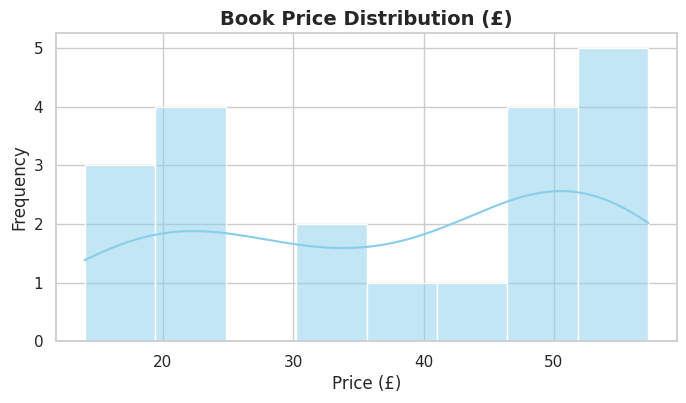

/tmp/ipykernel_1197/708958290.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5, x="Clean_Price", y="Book Title", palette="viridis")


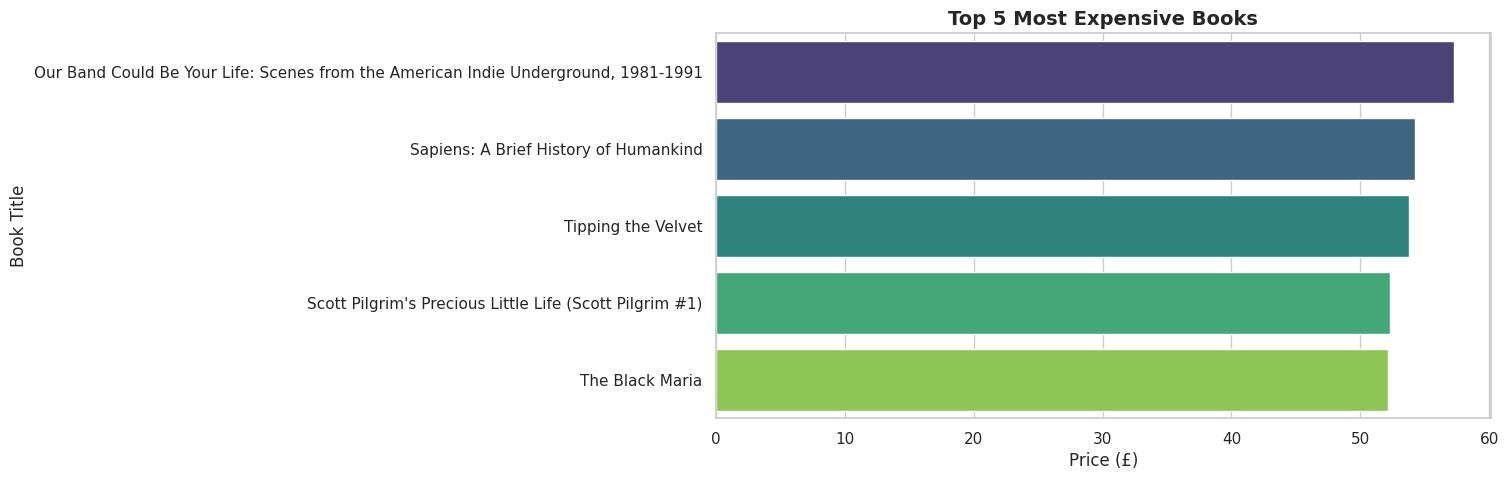

✅ Data Visualizations generated successfully!


In [2]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. FETCH & CLEAN DATA
url = "http://books.toscrape.com/"
response = requests.get(url)
soup = BeautifulSoup(response.text, "html.parser")

titles, prices = [], []
books = soup.find_all("article", class_="product_pod")

for book in books:
    titles.append(book.h3.a["title"])
    prices.append(book.find("p", class_="price_color").text)

df = pd.DataFrame({"Book Title": titles, "Price": prices})
df["Clean_Price"] = df["Price"].str.replace("Â", "").str.replace("£", "").astype(float)

# 2. SET STYLING
sns.set_theme(style="whitegrid")

# 3. CHART 1: Price Distribution
plt.figure(figsize=(8, 4))
sns.histplot(df["Clean_Price"], kde=True, color="skyblue", bins=8)
plt.title("Book Price Distribution (£)", fontsize=14, fontweight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

# 4. CHART 2: Top 5 Most Expensive Books
top_5 = df.nlargest(5, "Clean_Price")

plt.figure(figsize=(10, 5))
sns.barplot(data=top_5, x="Clean_Price", y="Book Title", palette="viridis")
plt.title("Top 5 Most Expensive Books", fontsize=14, fontweight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Book Title")
plt.show()

print("✅ Data Visualizations generated successfully!")